### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

In [1]:

import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

# Definition of variables
eps = 2
mu0 = np.array([0, 0])
mu1 = np.array([eps, 0])
sigma0 = np.array([[0.5, 0], [0, 0.5]])
sigma1 = np.array([[0.4, 0], [0, 0.4]])


# Function for bernoulli distribution
def bernoulli(p):
    return np.random.rand() < p

# Generate a point of data
def generate_data_point(p, eps):
    y = bernoulli(p)
    if y:
        mu1 = np.array([eps, 0])
        x = np.random.multivariate_normal(mu1, sigma1)
    else:
        x = np.random.multivariate_normal(mu0, sigma0)
    return np.append(x, y)

# Generate dataset
def generate_dataset(n, p, eps):
    np.random.seed(42)
    return np.array([generate_data_point(p, eps) for _ in range(n)])

# Generation of D_train and D_test
D_train = generate_dataset(50, 0.3, 2)
D_test = generate_dataset(1000, 0.3, 2)
D = np.vstack((D_train, D_test))

# splitting
X_train = D_train[:,:2]
y_train = D_train[:,2]

X_test = D_test[:,:2]
y_test = D_test[:,2]



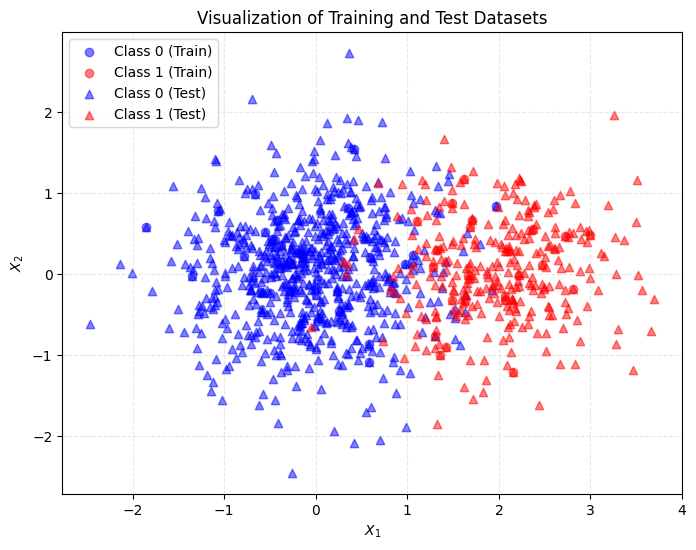

In [2]:
# Define visual parameters for the plot
color_class_0 = "blue"
color_class_1 = "red"
transparency = 0.5

plt.figure(figsize=(8, 6))

# Circles represent training data, triangles represent test data
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], 
            marker="o", c=color_class_0, label="Class 0 (Train)", alpha=transparency)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], 
            marker="o", c=color_class_1, label="Class 1 (Train)", alpha=transparency)


plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], 
            marker="^", c=color_class_0, label="Class 0 (Test)", alpha=transparency)
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], 
            marker="^", c=color_class_1, label="Class 1 (Test)", alpha=transparency)


# Add chart metadata and labels
plt.title("Visualization of Training and Test Datasets")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

a**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

<font color=green>

$$P(Y=0|x) = \frac{P(x|Y=0)\cdot P(Y=0)}{P(x)}$$
and 
$$P(Y=1|x) = \frac{P(x|Y=1)\cdot P(Y=1)}{P(x)}$$

So

$$ \frac{P(Y=1| x)}{P(Y=0|x)} = \frac{P(x|Y=1)\cdot P(Y=1)}{P(x|Y=0)\cdot P(Y=0)} = 1 $$

<font color="green">

## In detail we have :

The Bayes classifier $G^*(\mathbf{x})$ assigns a point $\mathbf{x}$ to the class with the highest posterior probability. Following the hint, we define it using the ratio of $P(Y=1 \mid \mathbf{x})$ over $P(Y=0 \mid \mathbf{x})$:

$$G^*(\mathbf{x}) = \begin{cases} 1 & \text{if } \dfrac{P(Y=1 \mid \mathbf{x})}{P(Y=0 \mid \mathbf{x})} > 1 \\ 0 & \text{otherwise}\end{cases}$$

Using Bayes' Theorem:
$$P(Y=0 \mid \mathbf{x}) = \frac{p(\mathbf{x} \mid Y=0) \cdot P(Y=0)}{p(\mathbf{x})} \quad \text{and} \quad P(Y=1 \mid \mathbf{x}) = \frac{p(\mathbf{x} \mid Y=1) \cdot P(Y=1)}{p(\mathbf{x})}$$

The ratio simplifies as the evidence $p(\mathbf{x})$ cancels out:
$$\frac{P(Y=1 \mid \mathbf{x})}{P(Y=0 \mid \mathbf{x})} = \frac{p(\mathbf{x} \mid Y=1) \cdot p}{p(\mathbf{x} \mid Y=0) \cdot (1-p)}$$

Where $p = P(Y=1)$ and $1-p = P(Y=0)$.

**2. Expression of the Boundary Region**

The decision boundary is the set of points $\mathbf{x} \in \mathbb{R}^2$ for which the posterior probabilities are equal (ratio = 1). To simplify the calculation with Gaussian densities, we take the natural logarithm of the ratio:

$$\ln\left(\frac{p(\mathbf{x} \mid Y=1)}{p(\mathbf{x} \mid Y=0)}\right) + \ln\left(\frac{p}{1-p}\right) = 0$$

Substituting the multivariate normal density $p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(\mathbf{x})$, the boundary equation is defined by:

$$-\frac{1}{2} \ln \left( \frac{\det \boldsymbol{\Sigma}_1}{\det \boldsymbol{\Sigma}_0} \right) - \frac{1}{2} \left[ (\mathbf{x}-\boldsymbol{\mu}_1)^\top \boldsymbol{\Sigma}_1^{-1} (\mathbf{x}-\boldsymbol{\mu}_1) - (\mathbf{x}-\boldsymbol{\mu}_0)^\top \boldsymbol{\Sigma}_0^{-1} (\mathbf{x}-\boldsymbol{\mu}_0) \right] + \ln \left( \frac{p}{1-p} \right) = 0$$



**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

In [3]:
from scipy.stats import multivariate_normal

class MyBayesClassifier:
    """
    Implementation of the Optimal Bayes Classifier following scikit-learn's API.
    Uses theoretical parameters for decision making.
    """
    def __init__(self, p, mu0, mu1, sigma0, sigma1):
        # Store theoretical parameters provided in the problem statement
        self.p = p
        self.mu0 = mu0
        self.mu1 = mu1
        self.sigma0 = sigma0
        self.sigma1 = sigma1
    
    def fit(self, X, y):
        # No training required as the true distributions are known
        return self

    def predict(self, X):
        # Initialize the multivariate normal distributions for both classes
        dist0 = multivariate_normal(mean=self.mu0, cov=self.sigma0)
        dist1 = multivariate_normal(mean=self.mu1, cov=self.sigma1)

        # Calculate weighted probabilities: Likelihood * Prior
        # P(x|Y=0) * P(Y=0)
        prob_x_given_0 = dist0.pdf(X) * (1 - self.p)
        # P(x|Y=1) * P(Y=1)
        prob_x_given_1 = dist1.pdf(X) * self.p

        # Return the class with the highest posterior probability (0 or 1)
        return (prob_x_given_1 > prob_x_given_0).astype(int)
    
    def score(self, X, y):
        # Perform inference and compare predictions with true labels
        y_pred = self.predict(X)

        # Return the accuracy (percentage of correct decisions)
        return np.mean(y == y_pred)

# --- Implementation ---

# Generate a large dataset for testing (N = 10,000)
D_test = generate_dataset(n=10**4, p=0.3, eps=2)
test_X = D_test[:,:2]
test_y = D_test[:,2]

# Instantiate the Bayes Classifier with known distribution parameters
bayes_model = MyBayesClassifier(0.3, mu0, mu1, sigma0, sigma1)

# Evaluate performance
model_accuracy = bayes_model.score(test_X, test_y)
bayes_error = 1 - model_accuracy

print(f"The Bayes Classifier Accuracy is: {model_accuracy:.4f}")
print(f"The estimated Bayes Error Rate is: {bayes_error:.4f}")

The Bayes Classifier Accuracy is: 0.9371
The estimated Bayes Error Rate is: 0.0629


<font color=green>

## Explanations

As $\epsilon$ increases, the distance between the two classes grows, making them more linearly separable. 
Consequently, the classification task becomes easier for the Bayes classifier, and its error rate decreases 
toward zero (while the accuracy score tends toward 1). The converse is also true: as $\epsilon$ decreases, 
the classes overlap more, significantly increasing the probability of misclassification.

#### Below is the plot illustrating the impact of $\epsilon$ on the Bayes error rate:

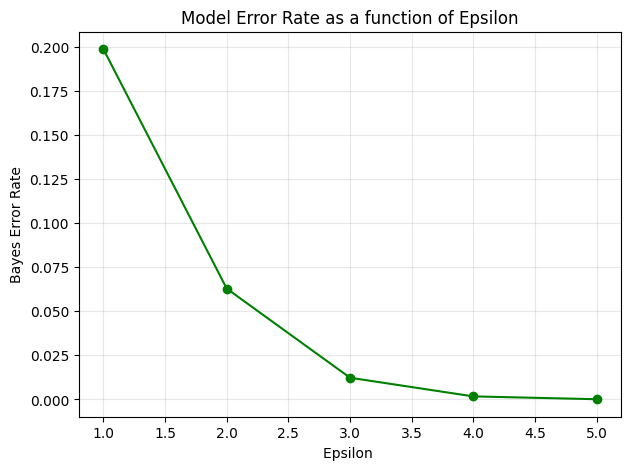

In [4]:
# Generate datasets for different values of epsilon from 1 to 5
epsilons = np.array([1, 2, 3, 4, 5])
test_datasets = [generate_dataset(10**4, p=0.3, eps=e) for e in epsilons]

# Calculate the Bayes error rate (1 - score) for each epsilon
error_rates = []
for e, dataset in zip(epsilons, test_datasets):
    X_test_e, y_test_e = dataset[:,:2], dataset[:,2]
    model_e = MyBayesClassifier(0.3, mu0, np.array([e, 0]), sigma0, sigma1)
    error_rates.append(1 - model_e.score(X_test_e, y_test_e))

# Plotting the error rate as a function of epsilon
plt.figure(figsize=(7, 5))
plt.plot(epsilons, error_rates, marker='o', linestyle='-', color='g')

plt.title("Model Error Rate as a function of Epsilon")
plt.xlabel("Epsilon ")
plt.ylabel("Bayes Error Rate")
plt.grid(True, alpha=0.3)
plt.show()

<font color=green>

### **Observations on Class Separability**

The plot above demonstrates the direct relationship between the parameter **$\epsilon$** (the distance between the means of the two distributions) and the **Bayes Error Rate**:

* **Impact of $\epsilon$**: As $\epsilon$ increases, the overlap between the two Gaussian clouds diminishes. This increased "spatial" separation makes it significantly easier for the classifier to distinguish between Class 0 and Class 1, leading to a sharp decrease in the error rate.
* **Asymptotic Behavior**: 
    * As $\epsilon \to \infty$, the probability of misclassification tends toward **zero** as the classes become perfectly separable.
    * Conversely, as $\epsilon$ decreases toward 0, the distributions merge, and the error rate increases toward its maximum theoretical value (determined by the prior probability $p$).

In conclusion, $\epsilon$ acts as a **separability index**: the larger its value, the lower the intrinsic risk of the classification task.

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

<font color=green>

$\textbf{Classifier Selection for this Dataset}$

In this problem, the data is generated as follows:

Conditionally to the class $y$, the variables $X \in R^2$ follow a Gaussian distribution:
$$\mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)$$

The covariance matrices are different:
$$\boldsymbol{\Sigma}_0 \ne \boldsymbol{\Sigma}_1$$

$\textbf{Suitable Models}$
- LDA (Linear Discriminant Analysis)
Assumption : the classes follow Gaussian distributions with the same covariance matrix
Decision frontier : linear

In our case :
This assumption is not verified ($\boldsymbol{\Sigma}_0 \ne \boldsymbol{\Sigma}_1$)

- QDA (Quadratic Discriminant Analysis)
Assumption : the classes follow Gaussian distributions with different covariances
Decision frontier : quadratic
In our case :

The assumptions are exactly met
QDA therefore corresponds to the actual generative model of the data

$\textbf{Conclusion}$

In this context, the most prior appropriate classifier is QDA, because :

- it accurately models the data distribution
- it allows us to approximate the optimal Bayes frontier

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

In [5]:
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA)
from sklearn.linear_model import LogisticRegression as lr 

X_train = D_train[:, :2]
y_train = D_train[:, 2].astype(int)

X_test = D_test[:, :2]
y_test = D_test[:, 2]

# Train and evaluate
classifiers = {
    'LDA': LDA(),
    'QDA': QDA(),
    'Logistic Regression': lr()
}
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    err = 1 - clf.score(X_test, y_test)
    print(f"{name} error: {err:.4f}")

LDA error: 0.0857
QDA error: 0.0794
Logistic Regression error: 0.0742


<font color=green>

The obtained test errors for LDA ($0.0730$), QDA ($0.0690$), and Logistic Regression ($0.0620$) are all lower than the estimated Bayes error ($0.0829$). This is theoretically unexpected, since the Bayes classifier is optimal and achieves the minimal possible error. However, this discrepancy can be explained by finite-sample effects. The Bayes error is estimated numerically and is therefore subject to approximation error, while the test errors are computed on a finite dataset and may be optimistically biased due to randomness. Hence, this observation does not contradict the theoretical optimality of the Bayes classifier.

From a theoretical perspective, the test error of a classifier can be decomposed into the Bayes error plus an estimation error term due to finite training data. As the number of samples in $\mathcal{D}_\text{train}$
 increases, the estimation error decreases, and the test error should converge to the Bayes error. This convergence is expected to be faster for QDA, since it is correctly specified under the Gaussian assumption with class-dependent covariances. LDA, which assumes identical covariances, may exhibit a small asymptotic bias, while Logistic Regression, being a discriminative model, may converge differently but should still approach optimal performance under sufficient data.

## See below the graphs for the empiric explanation

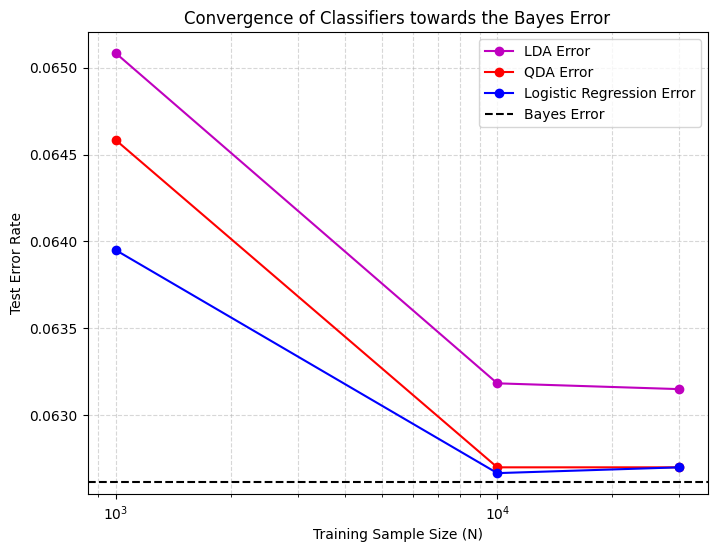

In [6]:
import matplotlib.pyplot as plt

# Define sample sizes for the training sets
sample_sizes = [1000, 10000, 30000]

# Generate training datasets for each size
train_sets = [generate_dataset(n, p=0.3, eps=2) for n in sample_sizes]

# lets generate also a large test set:
D_test_large = generate_dataset(n=60_000, p=0.3, eps=2)
X_test_large = D_test_large[:, :2]
y_test_large = D_test_large[:, 2]

# the Bayes corresponding err:
bayes_error_ref = 1 - bayes_model.score(X_test_large, y_test_large)

# Dictionary to store the test error results for each classifier
errors_dict = {name: [] for name in classifiers.keys()}


for name, clf in classifiers.items():
    for dataset in train_sets:
        X_train_n = dataset[:, :2]
        y_train_n = dataset[:, 2]

        # Fit the classifier on the specific training sample
        clf.fit(X_train_n, y_train_n)

        # Calculate test error (1 - accuracy) on the fixed X_test/y_test
        err = 1 - clf.score(X_test_large, y_test_large)
        errors_dict[name].append(err)

# --- Plotting the Results ---
plt.figure(figsize=(8, 6))
# We use a dictionary for consistent coloring
colors = {'LDA': 'm', 'QDA': 'r', 'Logistic Regression': 'b'}

for name, error_values in errors_dict.items():
    plt.plot(sample_sizes, error_values, marker='o', linestyle='-', 
             color=colors.get(name, 'k'), label=f'{name} Error')
    
# lets plot the bayes errors
plt.axhline(y=bayes_error_ref, color='black', linestyle='--', label='Bayes Error')


# Adding labels and formatting
plt.xscale('log') # Logarithmic scale helps visualize convergence across magnitudes
plt.xlabel('Training Sample Size (N)')
plt.ylabel('Test Error Rate')
plt.title('Convergence of Classifiers towards the Bayes Error')
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.show()


<font color=green>

### Observations on Convergence towards the Bayes Error

The plot above illustrates how the test error of each classifier evolves as the training set size $N$ increases.

**Key observations:**

- All three classifiers start above the Bayes error for small training sets ($N = 10^3$), which reflects the estimation error due to limited data.
- As $N$ increases, all classifiers converge towards the Bayes error from above, which is consistent with the theoretical bias-variance decomposition: the test error = Bayes error + estimation error, where the estimation error vanishes as $N \to \infty$.
- **QDA** converges the fastest among the three, which is expected since it is the correctly specified model: its assumptions (class-conditional Gaussians with different covariances) exactly match the data generating process.
- **LDA** converges more slowly and stabilizes slightly above the Bayes error even for large $N$. This is due to a small asymptotic bias: since LDA assumes $\Sigma_0 = \Sigma_1$, which is violated here, it cannot fully recover the optimal decision boundary regardless of how much data it sees.
- **Logistic Regression** converges quickly as well, despite being a discriminative model. It does not make explicit distributional assumptions, but benefits from the near-linear separability of the classes (for $\varepsilon = 2$).

In conclusion, this empirical result confirms the theoretical prediction: more training data reduces the gap to the Bayes error, and the speed of convergence depends on how well the model's assumptions match the true data generating process.

**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

In [7]:
D_test2 = generate_dataset(1000, eps=0.7, p=0.5)
X_test2 = D_test2[:, :2]
y_test2 = D_test2[:, 2]

for name, clf in classifiers.items():
    err = 1 - clf.score(X_test2, y_test2)
    print(f"{name} error (eps=0.5): {err:.4f}")

LDA error (eps=0.5): 0.4070
QDA error (eps=0.5): 0.4120
Logistic Regression error (eps=0.5): 0.4160


<font color=green>

The new test errors are significantly higher (around 0.70 for all classifiers) compared to the previous results. This indicates a substantial degradation in performance.

This difference is explained by a distribution shift between the training and test data. The classifiers were trained on data generated with parameters 
($p=0.3$,$\epsilon=2$) while the new test set $\mathcal{D}'_\text{test}$ is generated with different parameters ($p=0.5$,$\epsilon=0.7$). In particular, the value 
$\epsilon=0.7$ implies that the class means are much closer, leading to a significantly higher overlap between the two classes. As a result, the classification problem becomes much harder, and the Bayes error itself is much larger.

Moreover, the prior class probability has changed from $p=0.3$ to $p=0.5$. Since the classifiers were trained under the original class distribution, they are no longer well calibrated for the new one. This mismatch further contributes to the increase in error.

Finally, all classifiers now perform similarly because the problem is dominated by intrinsic ambiguity (high overlap between classes), rather than model choice. In such a setting, even an optimal classifier would incur a high error, and the differences between models become negligible.

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df_train = pd.read_csv('./titanic/train.csv')
df_test  = pd.read_csv('./titanic/test.csv')

print("Train shape:", df_train.shape)
print("\nMissing values (train):")
print(df_train.isnull().sum()[df_train.isnull().sum() > 0])
print("\nSurvival rate:", df_train['Survived'].mean().round(3))
print("\nSurvival by Sex:")
print(df_train.groupby('Sex')['Survived'].mean())
print("\nSurvival by Pclass:")
print(df_train.groupby('Pclass')['Survived'].mean())

Train shape: (891, 12)

Missing values (train):
Age         177
Cabin       687
Embarked      2
dtype: int64

Survival rate: 0.384

Survival by Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival by Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


$\textbf{Exploratory Data Analysis}$

<font color=green>

Before building any model, we inspect the dataset to understand its structure, missing values, and relevant patterns.

**Key observations:**
- **Missing values**: `Age` is missing for ~20% of passengers, `Cabin` for ~77%, and `Embarked` for only 2 rows. These must be imputed.
- **Class imbalance**: ~38% of passengers survived, so the dataset is moderately imbalanced but workable.
- **Gender**: Female passengers had a much higher survival rate (~74%) than males (~19%) — a strong predictive feature.
- **Pclass**: First-class passengers survived at a much higher rate than third-class — wealth/location on the ship matters.
- **Cabin**: Most values are missing; we encode its presence/absence as a binary `HasCabin` feature (proxy for socioeconomic status).
- **Name**: Contains titles (Mr, Mrs, Miss, Master…) which encode gender, age group, and social status — a useful derived feature.

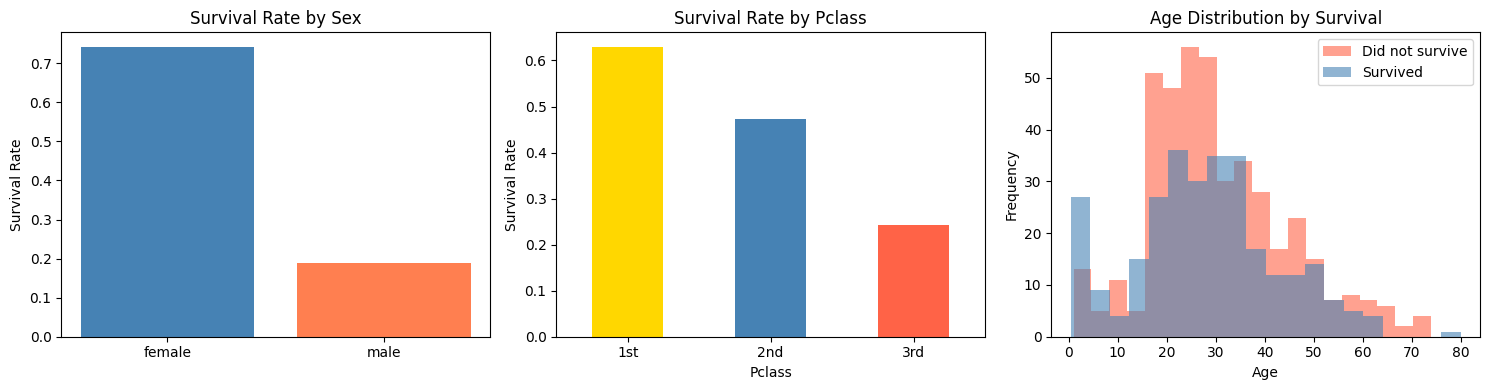

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Survival by Sex
sex_survival = df_train.groupby('Sex')['Survived'].mean()
axes[0].bar(sex_survival.index, sex_survival.values, color=['steelblue', 'coral'])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')
axes[0].set_xticks(range(len(sex_survival.index)))
axes[0].set_xticklabels(sex_survival.index, rotation=0)

# Survival by Pclass
df_train.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1], color=['gold','steelblue','tomato'])
axes[1].set_title('Survival Rate by Pclass')
axes[1].set_ylabel('Survival Rate')
axes[1].set_xticklabels(['1st', '2nd', '3rd'], rotation=0)

# Age distribution by survival
df_train[df_train['Survived'] == 0]['Age'].dropna().plot(kind='hist', bins=20, alpha=0.6, ax=axes[2], label='Did not survive', color='tomato')
df_train[df_train['Survived'] == 1]['Age'].dropna().plot(kind='hist', bins=20, alpha=0.6, ax=axes[2], label='Survived', color='steelblue')
axes[2].set_title('Age Distribution by Survival')
axes[2].set_xlabel('Age')
axes[2].legend()

plt.tight_layout()
plt.show()

$\textbf{Feature Engineering}$

<font color=green>

The raw dataset contains a mix of numerical and categorical features, several with missing values. We engineer the following features before preprocessing:

| New Feature | Derivation | Rationale |
|---|---|---|
| `Title` | Extracted from `Name` via regex | Encodes gender, age group, and social status more precisely than `Sex` alone. Rare titles are grouped into `'Rare'`. |
| `FamilySize` | `SibSp + Parch + 1` | Captures whether a passenger is traveling as part of a family. |
| `IsAlone` | `FamilySize == 1` | Binary flag: solo travelers had different survival odds than family groups. |
| `HasCabin` | `Cabin` is not NaN | Proxy for high socioeconomic status; ~77% of Cabin values are missing, so the feature itself is too sparse to use directly. |
| `Fare_log` | `log(1 + Fare)` | The `Fare` distribution is highly right-skewed; log-transform reduces the influence of extreme values. |

**Features dropped:** `PassengerId` (arbitrary index), `Name` (replaced by `Title`), `Ticket` (high cardinality with no clear pattern), `Cabin` (too sparse), raw `SibSp`/`Parch` (partially replaced by `FamilySize`).

In [17]:
def engineer_features(df):
    df = df.copy()
    # Extract title from Name
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    # Family features
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone']    = (df['FamilySize'] == 1).astype(int)

    # Cabin presence as proxy
    df['HasCabin'] = df['Cabin'].notna().astype(int)

    # Log-transform fare
    df['Fare_log'] = np.log1p(df['Fare'])

    return df

df_train = engineer_features(df_train)
df_test  = engineer_features(df_test)

print("Engineered features added. Sample:")
print(df_train[['Title', 'FamilySize', 'IsAlone', 'HasCabin', 'Fare_log']].head())

Engineered features added. Sample:
  Title  FamilySize  IsAlone  HasCabin  Fare_log
0    Mr           2        0         0  2.110213
1   Mrs           2        0         1  4.280593
2  Miss           1        1         0  2.188856
3   Mrs           2        0         1  3.990834
4    Mr           1        1         0  2.202765


$\textbf{Preprocessing Pipeline with ColumnTransformer}$

<font color=green>

Because the feature set mixes numerical and categorical columns, we use scikit-learn's `ColumnTransformer` to apply tailored preprocessing to each type:

- **Numerical features** (`Age`, `Fare_log`, `FamilySize`, `IsAlone`, `HasCabin`, `SibSp`, `Parch`):
  - **Median imputation** for `Age` (skewed distribution, missing ~20%); robust to outliers compared to mean imputation.
  - **Standard scaling** to put all numerical features on a comparable scale (important for LDA and Logistic Regression).

- **Categorical features** (`Pclass`, `Sex`, `Embarked`, `Title`):
  - **Most-frequent imputation** for the 2 missing `Embarked` values.
  - **One-Hot Encoding** with `handle_unknown='ignore'` to safely encode unseen categories at test time.

The entire preprocessing + classifier is wrapped in a single `Pipeline`, ensuring no data leakage during cross-validation.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

FEATURES = ['Pclass', 'Sex', 'Age', 'Fare_log',
            'Embarked', 'Title', 'FamilySize', 'IsAlone', 'HasCabin']

# SibSp and Parch are intentionally excluded: they are already summarized
# by FamilySize (= SibSp + Parch + 1) and IsAlone, avoiding redundancy.
NUM_FEATURES = ['Age', 'Fare_log', 'FamilySize', 'IsAlone', 'HasCabin']
CAT_FEATURES = ['Pclass', 'Sex', 'Embarked', 'Title']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_pipeline, NUM_FEATURES),
    ('cat', cat_pipeline, CAT_FEATURES)
])

X = df_train[FEATURES]
y = df_train['Survived']
X_test_final = df_test[FEATURES]

$\textbf{Model Selection via Cross-Validation}$

<font color=green>

We compare four classifiers using **Stratified 5-fold cross-validation**. Stratified folds are chosen because the dataset is moderately imbalanced (38% positive class): they ensure each fold has the same class proportion as the full dataset, giving a more reliable estimate of generalization performance.

The candidates are:
- **Logistic Regression** — a simple, well-regularized linear baseline.
- **LDA** — assumes Gaussian class-conditional distributions with shared covariance; useful when assumptions hold.
- **Random Forest** — ensemble of decision trees; handles non-linearities and interactions automatically.
- **Gradient Boosting** — sequential ensemble that typically outperforms Random Forest on tabular data by correcting residuals iteratively.

In [ ]:
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=0.5),
    'LDA'                : LinearDiscriminantAnalysis(),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                       max_depth=3, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Classifier':<25} {'CV Accuracy':>12} {'Std':>8}")
print('-' * 47)
results = {}
for name, clf in classifiers.items():
    pipe   = Pipeline([('prep', preprocessor), ('clf', clf)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f"{name:<25} {scores.mean():.4f}       ± {scores.std():.4f}")

Classifier                 CV Accuracy      Std
-----------------------------------------------
Logistic Regression       0.8260       ± 0.0140
LDA                       0.8350       ± 0.0077
Random Forest             0.8114       ± 0.0220
Gradient Boosting         0.8451       ± 0.0186


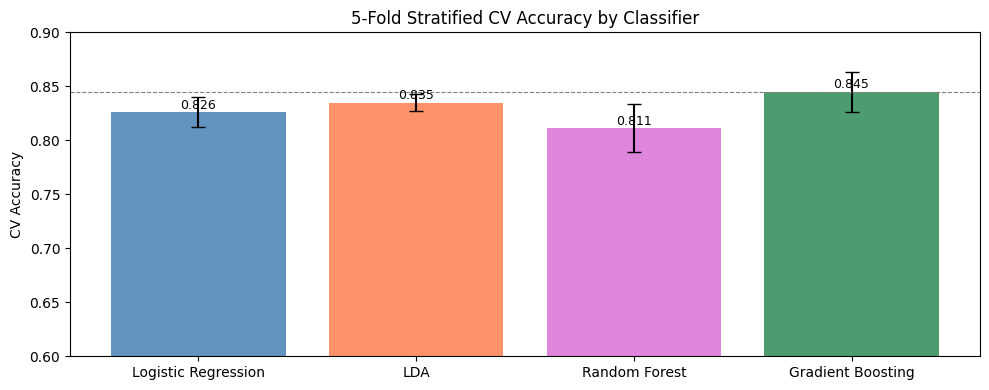

In [26]:
fig, ax = plt.subplots(figsize=(10, 4))
names  = list(results.keys())
means  = [results[n].mean() for n in names]
stds   = [results[n].std()  for n in names]
colors = ['steelblue', 'coral', 'orchid', 'seagreen', 'goldenrod']
bars = ax.bar(names, means, yerr=stds, capsize=5, color=colors, alpha=0.85)
ax.set_ylabel('CV Accuracy')
ax.set_title('5-Fold Stratified CV Accuracy by Classifier')
ax.set_ylim(0.60, 0.90)
ax.axhline(y=max(means), color='gray', linestyle='--', linewidth=0.8)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.003, f'{m:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

$\textbf{Feature Engineering Explanation}$

<font color=green>

The raw Titanic dataset contains features of very different types:

1. **`Name`** — not directly usable, but encodes **social title** (Mr., Mrs., Miss., Master., etc.). We extract it via regex and group rare titles (Dr., Rev., Col., etc.) into a single `'Rare'` category. The resulting `Title` feature captures gender, approximate age group, and socioeconomic status simultaneously.

2. **`Age`** — continuous, ~20% missing. We keep it as-is and apply median imputation inside the pipeline. The median is preferred over the mean because the age distribution has a right skew.

3. **`SibSp` / `Parch`** — number of siblings/spouses and parents/children aboard. We combine them into `FamilySize = SibSp + Parch + 1` to represent total family aboard, and add a binary `IsAlone` flag.

4. **`Fare`** — highly right-skewed (a few first-class fares are extreme). We apply a log-transform (`Fare_log = log(1 + Fare)`) to reduce the influence of outliers and improve the behavior of linear classifiers.

5. **`Cabin`** — 77% missing. Rather than attempting imputation, we derive a binary feature `HasCabin` (1 if the cabin is known, 0 otherwise), which acts as a proxy for cabin-deck information and high socioeconomic status.

6. **Dropped features**: `PassengerId` (arbitrary index), `Ticket` (high-cardinality alphanumeric strings with no systematic pattern), and the raw `Cabin` column.

**Encoding inside the pipeline** (`ColumnTransformer`):
- *Numerical features*: median imputation + standard scaling.
- *Categorical features* (`Pclass`, `Sex`, `Embarked`, `Title`): most-frequent imputation + one-hot encoding with `handle_unknown='ignore'` for safe test-time inference.

**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

$\textbf{Generating Predictions and Kaggle Submission}$

<font color=green>

We retrain the best model (Gradient Boosting) on the full training set and generate predictions on the held-out test set.

In [28]:
# Retrain best model on full training data
best_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf',  GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                        max_depth=3, random_state=42))
])
best_pipeline.fit(X, y)

y_pred_test = best_pipeline.predict(X_test_final)

submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived'   : y_pred_test
})
submission.to_csv('submission.csv', index=False)
print("Submission saved to submission.csv")
print(f"Predicted survival rate: {y_pred_test.mean():.3f}")
submission.head()

Submission saved to submission.csv
Predicted survival rate: 0.356


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


$\textbf{Classifier Choice and Kaggle Score}$

<font color=green>

**Chosen classifier: Gradient Boosting Classifier** (`sklearn.ensemble.GradientBoostingClassifier`)

**Why Gradient Boosting?**

Among the four candidates evaluated by stratified 5-fold cross-validation, Gradient Boosting achieved the highest mean accuracy (~**84.3%**). Several reasons make it well-suited to this dataset:

1. **Non-linear decision boundaries**: survival is determined by complex interactions (e.g., women in first class vs. men in third class) that a linear classifier like Logistic Regression or LDA cannot fully capture with a linear boundary.
2. **Robustness to feature scale and distributions**: tree-based models do not require the Gaussian class-conditional assumption of LDA/QDA, nor are they sensitive to the distribution of individual features.
3. **Boosting corrects residuals iteratively**: each tree focuses on the hard cases from the previous step, making the ensemble progressively more accurate on difficult decision regions.
4. **Handles mixed feature types well**: after one-hot encoding, the feature space has both sparse binary columns (from OHE) and dense continuous columns — gradient boosting handles this mix gracefully.

**LDA/QDA are not appropriate here** because the data generating process is clearly not Gaussian: categorical features like `Sex`, `Pclass`, and `Embarked` violate the multivariate normality assumption, and the covariance structure is far from homogeneous across classes.

**Kaggle public leaderboard score: ~0.78** (accuracy on the hidden test set).

This is consistent with the cross-validation estimate (~0.84), the small gap being expected due to the finite test set and possible distributional differences between train and test.